In [280]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import date

In [ ]:
## Chargement du dataset retail
df = pd.read_csv("data/retail_analysis.csv", encoding="latin1")

df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/2010 8:34,1.69,13047.0,United Kingdom


In [ ]:
# Affichage des noms de colonnes du dataset
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [ ]:
# Affichage des dimensions du dataset
df.shape

(541909, 8)

In [ ]:
# Affichage des informations générales : types de données, valeurs manquantes, etc.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [ ]:
# Calcul du nombre de valeurs uniques par colonne
df.nunique()

InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64

In [ ]:
# Calcul du nombre de valeurs manquantes par colonne
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [ ]:
# Calcul du nombre de lignes dupliquées
df.duplicated().sum()

np.int64(5268)

In [ ]:
# Suppression des lignes dupliquées
df.drop_duplicates()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [ ]:
# Conversion de la colonne "InvoiceDate" en format datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"],errors="coerce")

In [290]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:
# Affichage des pays uniques
df['Country'].unique()

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Austria',
       'Israel', 'Finland', 'Bahrain', 'Greece', 'Hong Kong', 'Singapore',
       'Lebanon', 'United Arab Emirates', 'Saudi Arabia',
       'Czech Republic', 'Canada', 'Unspecified', 'Brazil', 'USA',
       'European Community', 'Malta', 'RSA'], dtype=object)

In [ ]:
# Remplacement de la valeur "Unspecified" par une valeur manquante (NaN)
df.loc[df["Country"] == "Unspecified", "Country"] = pd.NA
df['Country'].unique()

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Austria',
       'Israel', 'Finland', 'Bahrain', 'Greece', 'Hong Kong', 'Singapore',
       'Lebanon', 'United Arab Emirates', 'Saudi Arabia',
       'Czech Republic', 'Canada', <NA>, 'Brazil', 'USA',
       'European Community', 'Malta', 'RSA'], dtype=object)

In [ ]:
# Nettoyage de la colonne CustomerID et suppression du ".0" à la fin

df['CustomerID'] = (
    df['CustomerID']
    .dropna()
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
)


In [ ]:
# Classification des types de transactions
df['TransactionType']='Sale'
df.loc[(df['Quantity']<0) & (df['InvoiceNo'].astype(str).str.startswith('C')),'TransactionType']='Return'
df.loc[(df['Quantity']<0) & (df['UnitPrice']==0),'TransactionType']='System_Adjustment'
df[df['TransactionType'] == 'System_Adjustment']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TransactionType
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom,System_Adjustment
4347,536764,84952C,NaN,-38,2010-12-02 14:42:00,0.0,NaN,United Kingdom,System_Adjustment
7188,536996,22712,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom,System_Adjustment
7189,536997,22028,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom,System_Adjustment
7190,536998,85067,NaN,-6,2010-12-03 15:30:00,0.0,NaN,United Kingdom,System_Adjustment
...,...,...,...,...,...,...,...,...,...
535333,581210,23395,check,-26,2011-12-07 18:36:00,0.0,NaN,United Kingdom,System_Adjustment
535335,581212,22578,lost,-1050,2011-12-07 18:38:00,0.0,NaN,United Kingdom,System_Adjustment
535336,581213,22576,check,-30,2011-12-07 18:38:00,0.0,NaN,United Kingdom,System_Adjustment
536908,581226,23090,missing,-338,2011-12-08 09:56:00,0.0,NaN,United Kingdom,System_Adjustment


In [ ]:
# Exclusion des ajustements système afin de conserver uniquement
# les transactions ayant un impact réel sur l'activité commerciale
# (ventes et retours clients)
df_business = df[df['TransactionType'] != 'System_Adjustment']

In [ ]:
# Classification des produits et non-produits
df_business = df_business.copy()
non_product_codes = [
    'POST','M','m','S','PADS','B',
    'D','C2','DOT','Adjust bad debt'
    'BANK CHARGES','AMAZONFEE','CRUK',
    'BANK CHARGES'
]

df_business['ProductType'] = 'Product'

df_business.loc[
    df_business['StockCode'].isin(non_product_codes) |
    df_business['StockCode'].str.startswith('gift_', na=False),
    'ProductType'
] = 'Non_Product'


In [297]:
df_business.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TransactionType,ProductType
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,Sale,Product
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Sale,Product
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,Sale,Product
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Sale,Product
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Sale,Product


In [ ]:
# Affichage des types de transactions uniques
df_business['TransactionType'].unique()

array(['Sale', 'Return'], dtype=object)

In [ ]:
# Affichage du nombre de valeurs manquantes dans la colonne "Description"
df_business['Description'].isna().sum()


np.int64(592)

In [ ]:
# Affichage des codes produits uniques commençant par une lettre et classés comme "Product"
df_filtered = df_business[
    (df_business['StockCode'].str.match(r'^[A-Za-z]', na=False)) &
    (df_business['ProductType'] == 'Product')
]
df_filtered['StockCode'].unique()

array(['DCGS0076', 'DCGS0003', 'DCGS0070', 'DCGS0069', 'DCGSSBOY',
       'DCGSSGIRL', 'DCGS0004'], dtype=object)

In [ ]:
# Mise en majuscules des codes produits pour assurer une uniformité dans les analyses ultérieures
df_business['StockCode'] = df_business['StockCode'].str.upper()


In [ ]:
# Identification des lignes techniques (ajustements système) pour les exclure des analyses commerciales
df_business['Is_Technical_Line']=(df_business['UnitPrice']==0)

In [ ]:
# Vérifier si un même code produit correspond à plusieurs descriptions
desc_per_code = df_business.groupby("StockCode")["Description"].nunique()
desc_per_code.value_counts().head(10)
# combien de StockCodes ont >1 description
(desc_per_code > 1).sum()


np.int64(335)

In [ ]:
# Nettoyage des descriptions produits : suppression des espaces superflus et des ponctuations en fin de texte
df_business['Description'] = (
    df_business['Description']
    .str.strip()                 # espaces début/fin
    .str.replace(r'[.,]+$', '', regex=True)  # point ou virgule en fin
)


df_business = df_business.loc[
    df_business["Is_Technical_Line"] == False
].copy()


In [ ]:
# Vérifier si un même code produit correspond à plusieurs descriptions
desc_per_code = df_business.groupby("StockCode")["Description"].nunique()

desc_per_code.value_counts().head(10)
# combien de StockCodes ont >1 description
(desc_per_code > 1).sum()


np.int64(212)

In [ ]:
# Sélection des StockCodes ayant toujours plus d'une description
remaining_codes = (
    desc_per_code
    .loc[lambda x: x > 1]
    .sort_values(ascending=False)
)

remaining_codes.head(10)


StockCode
23196    4
23236    4
23370    3
23535    3
23131    3
23396    3
22937    3
22776    3
23126    3
23413    3
Name: Description, dtype: int64

In [ ]:
# Fonction de mesure de similarité entre deux chaînes de caractères
from difflib import SequenceMatcher

def similarity(a, b):
    return SequenceMatcher(None, a, b).ratio()


In [ ]:
# Détection des descriptions produits similaires
# Pour chaque StockCode ayant plusieurs descriptions :
# - Comparaison de toutes les paires possibles de descriptions
# - Calcul d'un score de similarité à l'aide de SequenceMatcher
# - Conservation des paires ayant un score >= 0.80
import itertools
import pandas as pd

similar_candidates = []

for code in remaining_codes.index:
    g = df_business[df_business["StockCode"] == code]
    descs = g["Description"].dropna().unique()

    # comparer toutes les paires de descriptions
    for a, b in itertools.combinations(descs, 2):
        sim = similarity(a, b)
        if sim >= 0.80:
            similar_candidates.append({
                "StockCode": code,
                "Desc_1": a,
                "Desc_2": b,
                "Similarity": round(sim, 3)
            })

df_similar = pd.DataFrame(
    similar_candidates,
    columns=["StockCode", "Desc_1", "Desc_2", "Similarity"]
)

df_similar.sort_values("Similarity", ascending=False).head(10)


,StockCode,Desc_1,Desc_2,Similarity
48,23484,HEART TRELLISTRIPLE T-LIGHT HOLDER,HEART TRELLIS TRIPLE T-LIGHT HOLDER,0.986
37,23359,SET OF 12 T-LIGHTS VINTAGE DOILEY,SET OF 12 T-LIGHTS VINTAGE DOILY,0.985
119,23148,MINIATURE ANTIQUE ROSE HOOK IVORY,MINITURE ANTIQUE ROSE HOOK IVORY,0.985
24,23240,SET OF 4 KNICK KNACK TINS DOILEY,SET OF 4 KNICK KNACK TINS DOILEY,0.985
88,22932,BAKING MOULD TOFFEE CUP CHOCOLATE,BAKING MOULD TOFFEE CUP CHOCOLATE,0.985
96,21109,"LARGE CAKE TOWEL, CHOCOLATE SPOTS",LARGE CAKE TOWEL CHOCOLATE SPOTS,0.985
16,23366,SET 12 COLOURING PENCILS DOILY,SET 12 COLOURING PENCILS DOILEY,0.984
35,23325,RUSTIC STRAWBERRY JAMPOT SMALL,RUSTIC STRAWBERRY JAM POT SMALL,0.984
117,23145,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,0.984
46,23324,RUSTIC STRAWBERRY JAMPOT LARGE,RUSTIC STRAWBERRY JAM POT LARGE,0.984


In [ ]:
# Pour chaque paire de descriptions similaires, compter le nombre d'occurrences de chacune dans le dataset
def count_desc(code, desc):
    return df_business.loc[
        (df_business["StockCode"] == code) &
        (df_business["Description"] == desc)
    ].shape[0]

df_similar["Count_1"] = df_similar.apply(
    lambda r: count_desc(r["StockCode"], r["Desc_1"]), axis=1
)

df_similar["Count_2"] = df_similar.apply(
    lambda r: count_desc(r["StockCode"], r["Desc_2"]), axis=1
)


In [311]:
df_similar.head(5)

,StockCode,Desc_1,Desc_2,Similarity,Count_1,Count_2
0,23196,RETO LEAVES MAGNETIC SHOPPING LIST,LEAVES MAGNETIC SHOPPING LIST,0.906,3,2
1,23236,STORAGE TIN VINTAGE DOILEY,STORAGE TIN VINTAGE DOILY,0.980,2,213
2,23370,SET 36 COLOUR PENCILS DOILEY,SET 36 COLOURING PENCILS DOILY,0.931,3,155
3,23370,SET 36 COLOUR PENCILS DOILEY,SET 36 COLOURING PENCILS DOILEY,0.949,3,1
4,23370,SET 36 COLOURING PENCILS DOILY,SET 36 COLOURING PENCILS DOILEY,0.984,155,1


In [ ]:
# En fonction des résultats obtenus, décider manuellement pour chaque paire si les descriptions peuvent être fusionnées 
# ou si elles doivent être conservées telles quelles
df_similar = df_similar.copy()
df_similar["Manual_Action"] = ""        # MERGE / KEEP
df_similar["Final_Description"] = ""

In [ ]:
# Exporter le tableau des descriptions similaires pour revue manuelle
df_similar.to_excel("C:/Users/fakhr/OneDrive/Bureau/manual_description_review.xlsx", index=False)


In [ ]:
# Après revue manuelle, réimporter le tableau avec les décisions prises
df_reviewed = pd.read_excel(r"data\manual_description_review.xlsx")
df_reviewed.head(5)

,StockCode,Desc_1,Desc_2,Similarity,Count_1,Count_2,Manual_Action,Final_Description
0,23236,STORAGE TIN VINTAGE DOILEY,STORAGE TIN VINTAGE DOILY,0.980,2,213,MERGE,STORAGE TIN VINTAGE DOILY
1,23196,RETO LEAVES MAGNETIC SHOPPING LIST,LEAVES MAGNETIC SHOPPING LIST,0.906,3,2,MERGE,RETO LEAVES MAGNETIC SHOPPING LIST
2,23231,WRAP VINTAGE DOILEY,WRAP VINTAGE DOILY,0.974,2,94,MERGE,WRAP VINTAGE DOILY
3,17107D,"FLOWER FAIRY,5 SUMMER B'DRAW LINERS",FLOWER FAIRY 5 SUMMER DRAW LINERS,0.941,25,1,MERGE,FLOWER FAIRY 5 DRAWER LINERS
4,17107D,FLOWER FAIRY 5 DRAWER LINERS,FLOWER FAIRY 5 SUMMER DRAW LINERS,0.852,21,1,MERGE,FLOWER FAIRY 5 DRAWER LINERS


In [ ]:
# Application des corrections validées manuellement
for _, r in df_reviewed[df_reviewed["Manual_Action"] == "MERGE"].iterrows():

    stockcode = r["StockCode"]
    final_desc = r["Final_Description"]

    mask = df_business["StockCode"] == stockcode
    df_business.loc[mask, "Description"] = final_desc


In [325]:
desc_per_code = df_business.groupby("StockCode")["Description"].nunique()

desc_per_code.value_counts().head(10)
# combien de StockCodes ont >1 description
(desc_per_code > 1).sum()


np.int64(79)

In [ ]:
# Affichage des StockCodes ayant encore plusieurs descriptions différentes après nettoyage et fusion manuelle
remaining = (
    df_business.groupby("StockCode")["Description"]
    .nunique()
    .loc[lambda x: x > 1]
    .sort_values(ascending=False)
)

remaining.head(10)


StockCode
22776    3
21818    2
23527    2
23525    2
23524    2
23523    2
23522    2
23521    2
23489    2
23466    2
Name: Description, dtype: int64

In [ ]:
# Pour les StockCodes restants, on peut appliquer une règle de décision automatique basée sur un seuil de similarité plus bas (ex: 0.30)
#  pour identifier d'autres paires de descriptions potentiellement fusionnables
import itertools

similar_candidates = []

for code in remaining.index:
    g = df_business[df_business["StockCode"] == code]
    descs = g["Description"].unique()

    for a, b in itertools.combinations(descs, 2):
        sim = similarity(a, b)
        if sim >= 0.30:
            similar_candidates.append({
                "StockCode": code,
                "Desc_1": a,
                "Desc_2": b,
                "Similarity": round(sim, 3)
            })
df_similar = pd.DataFrame(
    similar_candidates,
    columns=["StockCode", "Desc_1", "Desc_2", "Similarity"]
)

df_similar.sort_values("Similarity", ascending=False).head(10)

,StockCode,Desc_1,Desc_2,Similarity
48,22785,SQUARECUSHION COVER PINK UNION FLAG,SQUARECUSHION COVER PINK UNION JACK,0.914
69,23232,WRAP VINTAGE PETALS DESIGN,WRAP VINTAGE LEAF DESIGN,0.863
68,23235,STORAGE TIN VINTAGE LEAF,BISCUIT TIN VINTAGE LEAF,0.792
75,23091,ZINC HERB GARDEN CONTAINER,METAL HERB GERDEN CONTAINER,0.792
17,23390,DOLLY GIRL MINI BACKPACK,DOLLY GIRL MINI RUCKSACK,0.792
37,23541,WALL ART CLASSIC PUDDINGS,"WALL ART ,PUDDINGS",0.791
78,23068,ALUMINIUM STAMPED HEART,ALUMINIUM HEART,0.789
72,23197,SKETCHBOOK MAGNETIC SHOPPING LIST,VEGETABLE MAGNETIC SHOPPING LIST,0.788
55,22502,PICNIC BASKET WICKER SMALL,PICNIC BASKET WICKER 60 PIECES,0.786
64,23015,CORDIAL GLASS JUG,CORDIAL JUG,0.786


In [ ]:
df_similar = pd.DataFrame(similar_candidates)

In [ ]:
# Pour chaque paire de descriptions similaires, compter le nombre d'occurrences de chacune dans le dataset
def count_desc(code, desc):
    return df_business.loc[
        (df_business["StockCode"] == code) &
        (df_business["Description"] == desc)
    ].shape[0]

df_similar["Count_1"] = df_similar.apply(
    lambda r: count_desc(r["StockCode"], r["Desc_1"]), axis=1
)

df_similar["Count_2"] = df_similar.apply(
    lambda r: count_desc(r["StockCode"], r["Desc_2"]), axis=1
)


In [ ]:
# En fonction des résultats obtenus, décider manuellement pour chaque paire si les descriptions peuvent être fusionnées 
# ou si elles doivent être conservées telles quelles
df_similar = df_similar.copy()
df_similar["Manual_Action"] = ""        # MERGE / KEEP
df_similar["Final_Description"] = ""

In [ ]:
# Exporter le tableau des descriptions similaires pour revue manuelle
df_similar.to_excel("C:/Users/fakhr/OneDrive/Bureau/manual_description_review1.xlsx", index=False)


In [ ]:
# Après revue manuelle, réimporter le tableau avec les décisions prises
df_reviewed = pd.read_excel(r"data\manual_description_review1.xlsx")


In [ ]:
# Application des corrections validées manuellement
for _, r in df_reviewed[df_reviewed["Manual_Action"] == "MERGE"].iterrows():

    stockcode = r["StockCode"]
    final_desc = r["Final_Description"]

    mask = df_business["StockCode"] == stockcode
    df_business.loc[mask, "Description"] = final_desc


In [ ]:
# Vérifier à nouveau le nombre de descriptions uniques par StockCode après cette seconde phase de nettoyage
desc_per_code = df_business.groupby("StockCode")["Description"].nunique()


# combien de StockCodes ont >1 description
(desc_per_code > 1).sum()


np.int64(0)

In [ ]:
# Affichage des StockCodes ayant encore plusieurs descriptions différentes après cette seconde phase de nettoyage et fusion manuelle
remaining = (
    df_business.groupby("StockCode")["Description"]
    .nunique()
    .loc[lambda x: x > 1]
    .sort_values(ascending=False)
)


In [ ]:
import itertools

similar_candidates = []

for code in remaining.index:
    g = df_business[df_business["StockCode"] == code]
    descs = g["Description"].unique()

    for a, b in itertools.combinations(descs, 2):
        sim = similarity(a, b)
        if sim >= 0.30:
            similar_candidates.append({
                "StockCode": code,
                "Desc_1": a,
                "Desc_2": b,
                "Similarity": round(sim, 3)
            })
df_similar = pd.DataFrame(
    similar_candidates,
    columns=["StockCode", "Desc_1", "Desc_2", "Similarity"]
)

df_similar.sort_values("Similarity", ascending=False).head(10)

# On ne peut pas modifier la description de ces produits
# Au début, on avait 317 StockCode avec plusieurs description et maintenant on a seulement 0 StockCode avec plusieurs descriptions différentes

,StockCode,Desc_1,Desc_2,Similarity


In [ ]:
# Préparation du dataset pour l'analyse des ventes et conservation uniquement des produits réels ("Product")
df_sales = df_business.copy()
df_sales = df_sales.loc[
    (df_sales['ProductType'] == 'Product') 
]
df_sales["Revenue"] = (df_sales["Quantity"] * df_sales["UnitPrice"]).round(2)

In [ ]:
# Conservation uniquement des colonnes pertinentes pour l'analyse des ventes
df_sales=df_sales[['InvoiceNo','StockCode','Description','InvoiceDate','Quantity','UnitPrice','Revenue','CustomerID','Country','TransactionType']].copy()

In [ ]:
# Normalisation de la colonne "InvoiceDate" pour ne conserver que la date sans l'heure, afin de faciliter les analyses temporelles ultérieures
df_sales['InvoiceDate'] = df_sales['InvoiceDate'].dt.normalize()


In [341]:
df_sales.head(2)

,InvoiceNo,StockCode,Description,InvoiceDate,Quantity,UnitPrice,Revenue,CustomerID,Country,TransactionType
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2010-12-01,6,2.55,15.30,17850,United Kingdom,Sale
1,536365,71053,WHITE METAL LANTERN,2010-12-01,6,3.39,20.34,17850,United Kingdom,Sale


In [ ]:
# Calcul du chiffre d'affaires total généré par les ventes
df_sales["Revenue"] = df_sales["Quantity"] * df_sales["UnitPrice"]
total_revenue_sales = df_sales["Revenue"].sum()
f"{total_revenue_sales:,.2f}"

'9,792,708.88'

In [ ]:
# Calcul du chiffre d'affaires total généré par les ventes, regroupé par pays
revenue_by_country=(
    df_sales.groupby('Country')['Revenue']
            .sum()
            .sort_values(ascending=False))
revenue_by_country.head(5).map(lambda x: f"{x:,.2f}")

Country
United Kingdom    8,301,718.28
Netherlands         283,479.54
EIRE                259,663.46
Germany             200,808.40
France              182,163.39
Name: Revenue, dtype: object

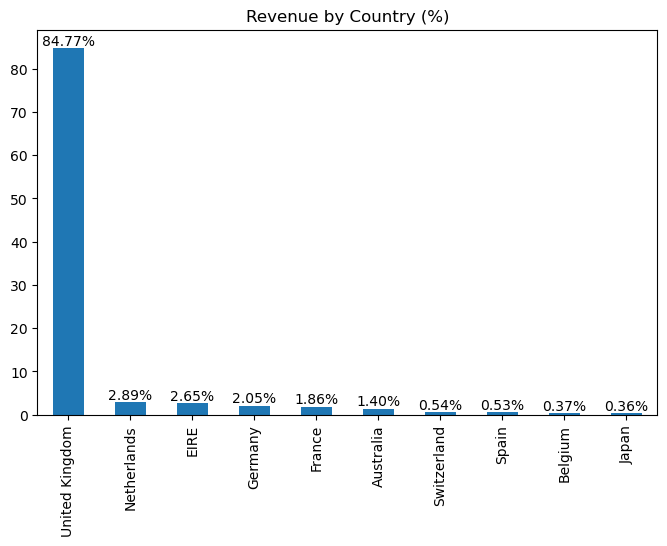

In [ ]:
# Visualisation du chiffre d'affaires par pays en pourcentage du total des ventes
data = ((revenue_by_country.head(10)/total_revenue_sales) * 100) .round(2)
ax = data .plot.bar(title = 'Revenue by Country (%)',figsize=(8,5),xlabel='')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%')

plt.show()

In [ ]:
# Calcul du nombre de clients uniques ayant effectué au moins un achat
df_sales['CustomerID'].nunique()

4362

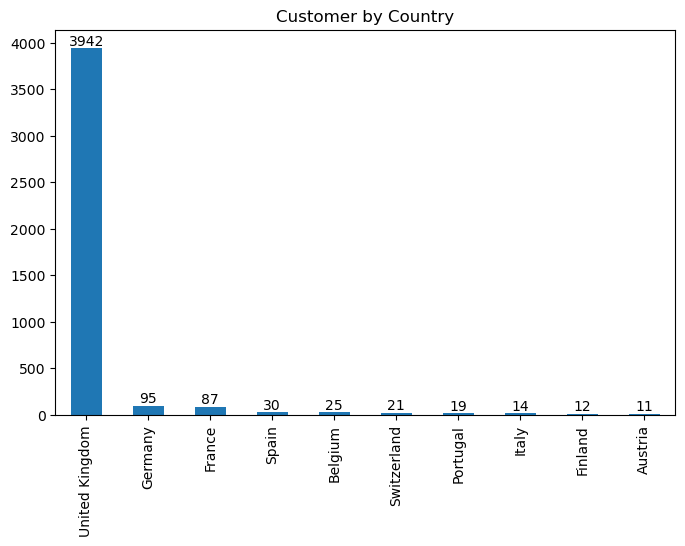

In [ ]:
# Analyse de la distribution géographique des clients :
# identification des pays générant le plus grand nombre de clients actifs.
client_by_country = (df_sales.dropna(subset=["CustomerID"])
                             .groupby('Country')['CustomerID']
                             .nunique()
                             .sort_values(ascending=False)
                    ).head(10)
ax = client_by_country.plot.bar(title = 'Customer by Country', xlabel='', ylabel='',figsize=(8,5))
for container in ax.containers:
    ax.bar_label(container)
plt.show()

In [ ]:
# Synthèse de la performance commerciale par pays : nombre de clients, chiffre d'affaires total et revenu moyen par client.
clients_by_country = (
    df_sales
    .dropna(subset=["CustomerID"])
    .groupby("Country")["CustomerID"]
    .nunique()
)

revenue_by_country = (
    df_sales
    .groupby("Country")["Revenue"]
    .sum()
)

summary_country = pd.DataFrame({
    "Clients": clients_by_country,
    "Revenue": revenue_by_country
})

summary_country["Avg_Revenue_per_Client"] = (
    summary_country["Revenue"] / summary_country["Clients"]
)

summary_country_valid = summary_country[summary_country['Clients']>0
                        ].sort_values("Avg_Revenue_per_Client", ascending=False)

summary_country_valid.map(lambda x: f"{x:,.2f}")


,Clients,Revenue,Avg_Revenue_per_Client
Country,,,
EIRE,3.00,"259,663.46","86,554.49"
Netherlands,9.00,"283,479.54","31,497.73"
Australia,9.00,"136,990.00","15,221.11"
Singapore,1.00,"9,120.39","9,120.39"
Japan,8.00,"35,419.79","4,427.47"
Sweden,8.00,"35,176.91","4,397.11"
Iceland,1.00,"4,310.00","4,310.00"
Norway,10.00,"32,292.96","3,229.30"
Switzerland,21.00,"52,505.35","2,500.25"


In [ ]:
# Malgré la domination du Royaume-Uni en volume de ventes et en nombre de clients,
# certains marchés secondaires (EIRE, Pays-Bas, Australie)
# affichent un revenu moyen par client nettement supérieur,
# suggérant la présence de clients à forte valeur ou d'un segment B2B.

In [ ]:
# Identification des clients les plus rentables : classement des clients par chiffre d'affaires total généré, 
# avec des informations complémentaires sur leur pays d'origine, le nombre de commandes passées et la quantité totale achetée.
Customer_by_revenue = (
    df_sales
    .dropna(subset=["CustomerID"])
    .groupby("CustomerID")
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Country=("Country", lambda x: x.dropna().mode().iat[0] if not x.dropna().mode().empty else "Unknown"),
        nb_orders=("InvoiceNo", "nunique"),
        total_quantity=("Quantity", "sum")
    )
).sort_values("Total_Revenue",ascending=False)

Customer_by_revenue.index = (
    Customer_by_revenue.index
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
)

Customer_by_revenue["Revenue"] = (
    Customer_by_revenue["Total_Revenue"]
    .map(lambda x: f"{x:,.2f}")
)
Top_Customer_by_revenue = Customer_by_revenue.head(10)
Top_Customer_by_revenue[["Revenue","Country","nb_orders","total_quantity"]]

,Revenue,Country,nb_orders,total_quantity
CustomerID,,,,
14646,"278,778.02",Netherlands,73,196556
18102,"259,657.30",United Kingdom,60,64124
17450,"189,735.53",United Kingdom,49,69041
14911,"128,882.13",EIRE,242,76848
12415,"123,638.18",Australia,24,76946
14156,"113,855.32",EIRE,64,57013
17511,"88,138.20",United Kingdom,45,63014
16684,"65,920.12",United Kingdom,30,49391
13694,"62,924.10",United Kingdom,57,61808


In [ ]:
# Pour mieux comprendre la répartition du chiffre d'affaires entre les clients, on peut calculer 
# le pourcentage de revenu généré par chaque client par rapport au total des ventes, 
# puis segmenter les clients en fonction de leur contribution au chiffre d'affaires (ex: Bottom 80%, 80–95%, 95–99%, Top 1%).
Customer_by_revenue["Revenue_percentile"] = (
    Customer_by_revenue["Total_Revenue"]
    .rank(pct=True)
)
Customer_by_revenue["Value_segment"] = pd.cut(
    Customer_by_revenue["Revenue_percentile"],
    bins=[0, 0.80, 0.95, 0.99, 1],
    labels=["Bottom 80%", "80–95%", "95–99%", "Top 1%"]
)
Customer_by_revenue[["Revenue","Country","nb_orders","total_quantity","Value_segment"]]


,Revenue,Country,nb_orders,total_quantity,Value_segment
CustomerID,,,,,
14646,"278,778.02",Netherlands,73,196556,Top 1%
18102,"259,657.30",United Kingdom,60,64124,Top 1%
17450,"189,735.53",United Kingdom,49,69041,Top 1%
14911,"128,882.13",EIRE,242,76848,Top 1%
12415,"123,638.18",Australia,24,76946,Top 1%
...,...,...,...,...,...
12666,-227.44,Israel,1,-56,Bottom 80%
16252,-295.09,United Kingdom,1,-158,Bottom 80%
16742,-464.90,United Kingdom,1,-190,Bottom 80%


In [351]:
threshold = Customer_by_revenue["Total_Revenue"].quantile(0.80)

high_value_customers = Customer_by_revenue[
    Customer_by_revenue["Total_Revenue"] >= threshold
].sort_values("Total_Revenue", ascending=False)
pct_revenue = (
    high_value_customers["Total_Revenue"].sum()
    / Customer_by_revenue["Total_Revenue"].sum()
) * 100

pct_revenue
# Les clients à forte valeur représentent 73.94% du chiffre d’affaires total, ce qui confirme qu’une petite fraction des clients
# génère la majorité des revenus.
# Ces clients doivent être prioritaires pour la rétention, la fidélisation et les offres premium.

np.float64(73.92806638124645)

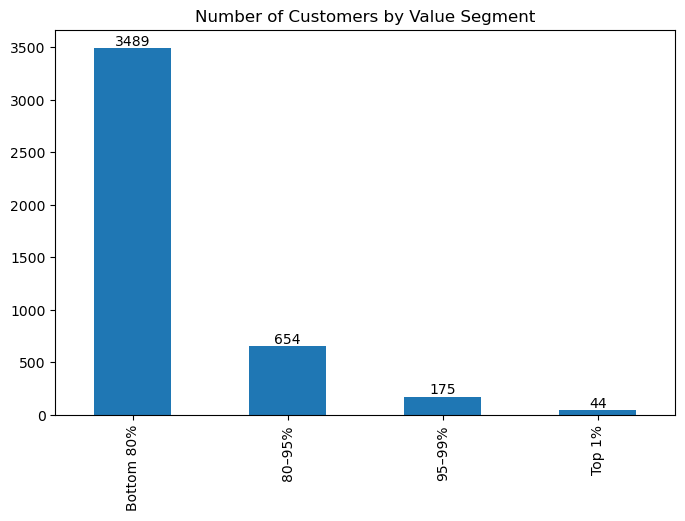

In [ ]:
# Visualisation de la répartition du nombre de clients par segment de valeur
segment_counts = (
    Customer_by_revenue["Value_segment"]
    .value_counts()
    .sort_index()
)

ax=segment_counts.plot.bar(figsize=(8,5),title="Number of Customers by Value Segment",xlabel="",ylabel="")

for container in ax.containers:
    ax.bar_label(container)


plt.show()

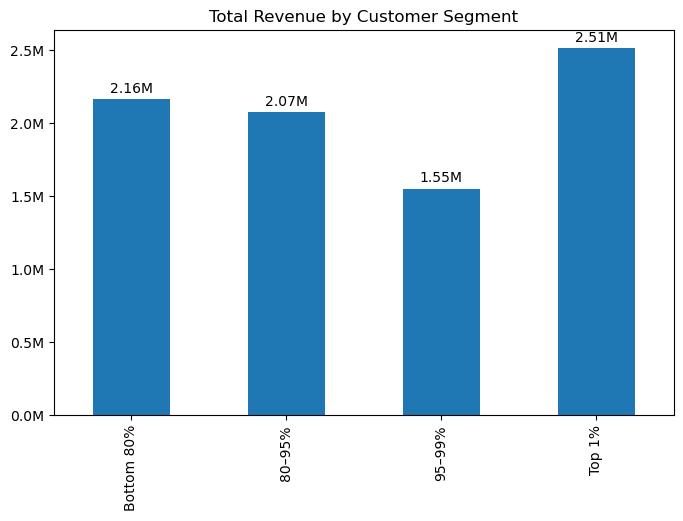

In [ ]:
import matplotlib.ticker as mtick

segment_revenue = (
    Customer_by_revenue
        .groupby("Value_segment",observed=False)['Total_Revenue']
        .sum()
        
)
ax = segment_revenue.plot(
    kind="bar",
    figsize=(8,5),
    title="Total Revenue by Customer Segment",
    xlabel="",
    ylabel=""
)

ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{v/1e6:.2f}M" for v in container.datavalues],
        padding=3
    )
    

plt.show()

# Une très faible proportion de clients (Top 1 %) génère une part disproportionnée du chiffre d’affaires,
# tandis que le Top 20 % constitue le véritable moteur de revenu du business. Le reste de la clientèle contribue
# de manière diffuse et nécessite une approche standardisée.

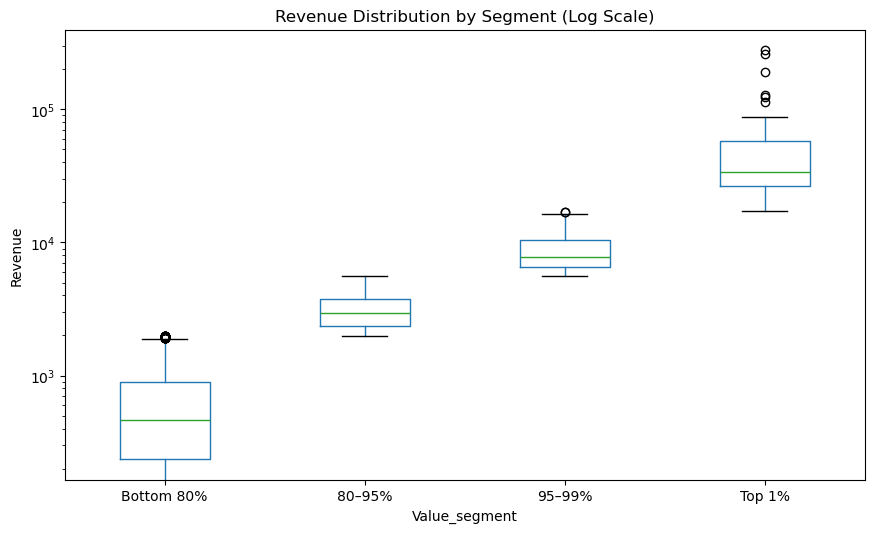

In [354]:
Customer_by_revenue.boxplot(
    column="Total_Revenue",
    by="Value_segment",
    figsize=(10,6),
    grid=False,
    xlabel="",
    ylabel="Revenue"
)
plt.yscale("log")
plt.title("Revenue Distribution by Segment (Log Scale)")
plt.suptitle("")
plt.show()

# La distribution du chiffre d’affaires est fortement asymétrique. 
# Les segments supérieurs ne se distinguent pas uniquement par un revenu moyen plus élevé, 
# mais aussi par une dispersion croissante et la présence de clients extrêmes, 
# soulignant la criticité du Top 1 % pour la performance globale.

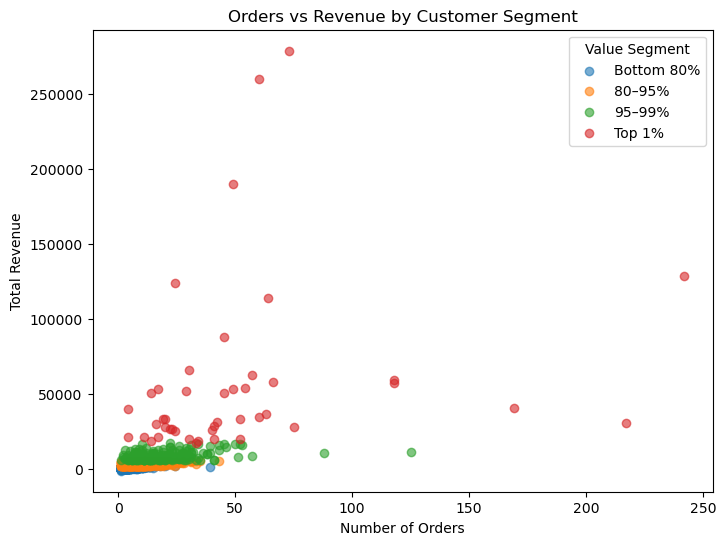

In [355]:
plt.figure(figsize=(8,6))

for segment, df_seg in Customer_by_revenue.groupby("Value_segment",observed=False):
    plt.scatter(
        df_seg["nb_orders"],
        df_seg["Total_Revenue"],
        label=segment,
        alpha=0.6
    )

plt.xlabel("Number of Orders")
plt.ylabel("Total Revenue")
plt.title("Orders vs Revenue by Customer Segment")
plt.legend(title="Value Segment")
plt.show()

# Le nuage de points montre que les segments de valeur ne sont pas uniquement déterminés par la fréquence d’achat.
# Les clients du Top 1 % et du Top 5 % se distinguent principalement par un panier moyen élevé,
# tandis que certains clients très fréquents restent dans des segments inférieurs en raison d’une faible valeur par commande.

In [ ]:
# Identification des produits les plus rentables : classement des produits par chiffre d'affaires total généré, 
# avec des informations complémentaires sur le nombre de commandes passées.
Product_by_revenue = (
    df_sales
    .groupby(["StockCode", "Description"], as_index=False)
    .agg(Total_Revenue=("Revenue", "sum"),
        nb_orders=("InvoiceNo", "nunique"))
    .sort_values("Total_Revenue", ascending=False)
)

Product_by_revenue["Revenue"] = (
    Product_by_revenue["Total_Revenue"]
    .map(lambda x: f"{x:,.2f}")
)


In [ ]:
# Identification des produits les plus performants
Top_Product_by_revenue= Product_by_revenue[["StockCode","Description","nb_orders","Revenue"]].head(10)
Top_Product_by_revenue

,StockCode,Description,nb_orders,Revenue
1308,22423,REGENCY CAKESTAND 3 TIER,2168,"164,762.19"
3323,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2307,"99,846.98"
2663,47566,PARTY BUNTING,1705,"98,302.98"
3307,85099B,JUMBO BAG RED RETROSPOT,2132,"92,356.03"
1940,23084,RABBIT NIGHT LIGHT,1009,"66,756.59"
1004,22086,PAPER CHAIN KIT 50'S CHRISTMAS,1170,"63,791.94"
3138,84879,ASSORTED COLOUR BIRD ORNAMENT,1467,"58,959.73"
2821,79321,CHILLI LIGHTS,667,"53,768.06"
1382,22502,PICNIC BASKET WICKER SMALL,472,"51,041.37"
1107,22197,POPCORN HOLDER,1442,"50,987.47"


In [ ]:
# Pour mieux comprendre la répartition du chiffre d'affaires entre les produits, on peut calculer 
# le pourcentage de revenu généré par chaque produit par rapport au total des ventes, 
# puis segmenter les produits en fonction de leur contribution au chiffre d'affaires (ex: Bottom 80%, 80–95%, 95–99%, Top 1%).
Product_by_revenue["Revenue_percentile"] = (
    Product_by_revenue["Total_Revenue"]
    .rank(pct=True)
)
Product_by_revenue["Value_segment"] = pd.cut(
    Product_by_revenue["Revenue_percentile"],
    bins=[0, 0.80, 0.95, 0.99, 1],
    labels=["Bottom 80%", "80–95%", "95–99%", "Top 1%"]
)
Product_by_revenue[["StockCode", "Description","nb_orders","Revenue","Value_segment"]]


,StockCode,Description,nb_orders,Revenue,Value_segment
1308,22423,REGENCY CAKESTAND 3 TIER,2168,"164,762.19",Top 1%
3323,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2307,"99,846.98",Top 1%
2663,47566,PARTY BUNTING,1705,"98,302.98",Top 1%
3307,85099B,JUMBO BAG RED RETROSPOT,2132,"92,356.03",Top 1%
1940,23084,RABBIT NIGHT LIGHT,1009,"66,756.59",Top 1%
...,...,...,...,...,...
2823,79323P,PINK CHERRY LIGHTS,3,-27.00,Bottom 80%
704,21645,ASSORTED TUTTI FRUTTI ROUND BOX,1,-39.60,Bottom 80%
2475,35400,WOODEN BOX ADVENT CALENDAR,13,-45.70,Bottom 80%
3285,85063,CREAM SWEETHEART MAGAZINE RACK,2,-46.85,Bottom 80%


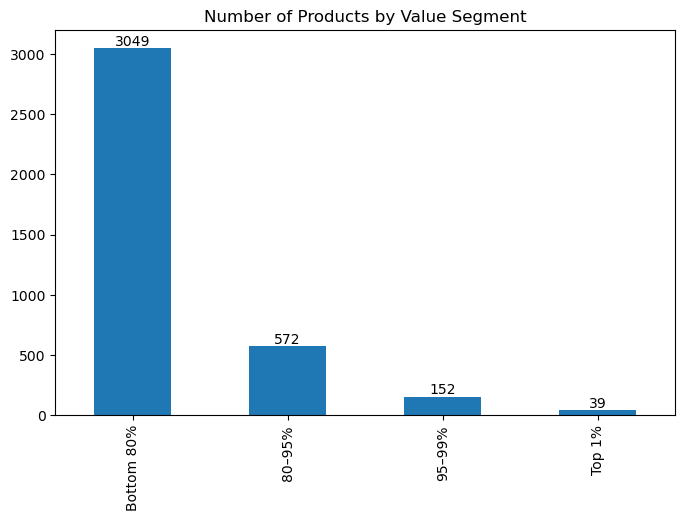

In [ ]:
# Répartition des produits par segment de valeur
segment_count_product = (Product_by_revenue['Value_segment']
                        .value_counts()
                        .sort_index())
ax = segment_count_product.plot.bar(figsize=(8,5),
                         title="Number of Products by Value Segment",xlabel=''
                        )
for container in ax.containers:
    ax.bar_label(container)
    
plt.show()

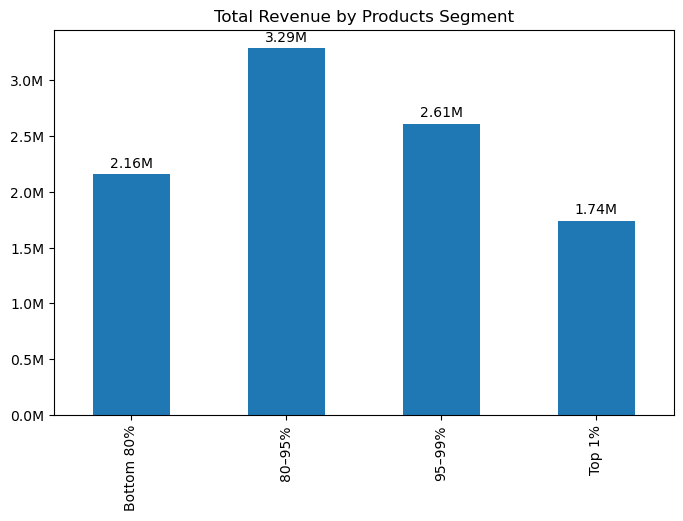

In [360]:
import matplotlib.ticker as mtick

segment_revenue = (
    Product_by_revenue
    .groupby("Value_segment",observed=False)["Total_Revenue"]
    .sum()
)

ax = segment_revenue.plot(
    kind="bar",
    figsize=(8,5),
    title="Total Revenue by Products Segment",
    xlabel=''
)

ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{v/1e6:.2f}M" for v in container.datavalues],
        padding=3
    )
    
plt.show()

# L’analyse de Pareto appliquée aux produits montre qu’une proportion très limitée de références génère
# l’essentiel du chiffre d’affaires. Le Top 20 % des produits constitue le cœur du catalogue, 
# tandis que la majorité des références contribue faiblement et peut faire l’objet d’une rationalisation.


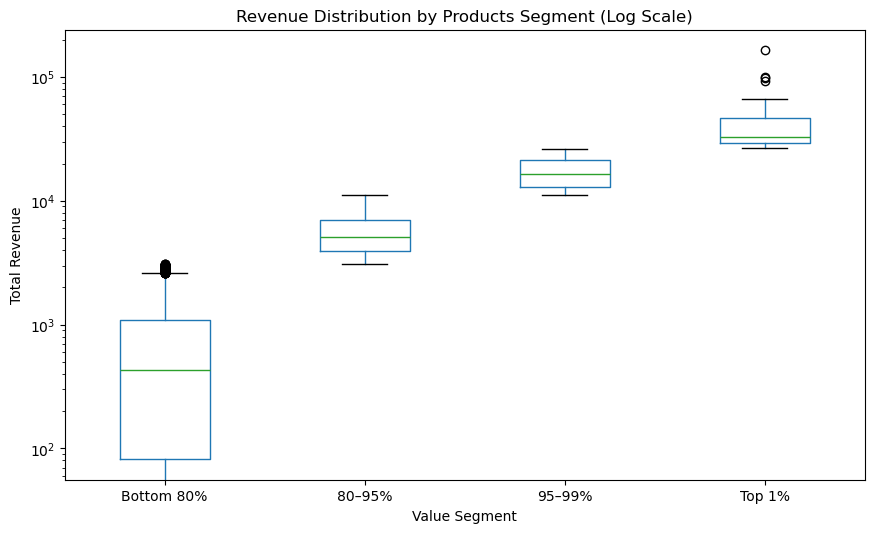

In [362]:
Product_by_revenue.boxplot(
    column="Total_Revenue",
    by="Value_segment",
    figsize=(10,6),
    grid=False
)
plt.yscale("log")
plt.title("Revenue Distribution by Products Segment (Log Scale)")
plt.suptitle("")
plt.xlabel("Value Segment")
plt.ylabel("Total Revenue")
plt.show()

# La distribution du chiffre d’affaires par produit est fortement asymétrique. 
# La majorité des références génère un revenu faible, tandis qu’un nombre très limité de produits concentre
# l’essentiel du chiffre d’affaires. Les produits du Top 1 % présentent à la fois des niveaux de revenu très élevés
# et une forte variabilité, soulignant leur caractère stratégique.
# Bottom 80 % → beaucoup de produits, peu de revenu
# Top 20 % → cœur du catalogue
# Top 5 % → produits premium
# Top 1 % → produits stratégiques

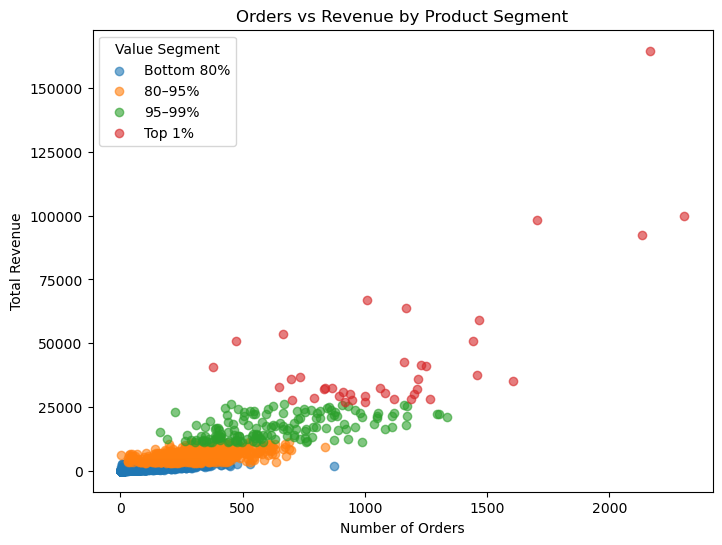

In [363]:
plt.figure(figsize=(8,6))

for segment, df_seg in Product_by_revenue.groupby("Value_segment",observed=False):
    plt.scatter(
        df_seg["nb_orders"],
        df_seg["Total_Revenue"],
        label=segment,
        alpha=0.6
    )

plt.xlabel("Number of Orders")
plt.ylabel("Total Revenue")
plt.title("Orders vs Revenue by Product Segment")
plt.legend(title="Value Segment")
plt.show()

# Le nuage de points met en évidence une relation positive mais très dispersée entre le nombre de commandes
# et le chiffre d’affaires par produit. Les produits du Top 1 % se distinguent principalement par un revenu unitaire élevé,
# tandis que certains produits très fréquemment commandés restent dans des segments inférieurs 
# en raison d’une faible valeur par commande.


In [364]:
Low_Product_revenue = (
    df_sales
    .groupby(["StockCode", "Description"], as_index=False)
    .agg(Total_Revenue=("Revenue", "sum"),
        nb_orders=("InvoiceNo", "nunique"))
    .sort_values("Total_Revenue", ascending=True)
)

Low_Product_revenue["Revenue"] = (
    Low_Product_revenue["Total_Revenue"]
    .map(lambda x: f"{x:,.2f}")
)

Low_Product_revenue=Product_by_revenue[["StockCode", "Description", "Revenue"]].head(20)
Low_Product_revenue
# L’analyse a identifié 19 produits présentant un chiffre d’affaires négatif, soit une proportion très marginale du catalogue.
# Ces cas sont considérés comme des anomalies ponctuelles (retours ou annulations)


,StockCode,Description,Revenue
1308,22423,REGENCY CAKESTAND 3 TIER,"164,762.19"
3323,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"99,846.98"
2663,47566,PARTY BUNTING,"98,302.98"
3307,85099B,JUMBO BAG RED RETROSPOT,"92,356.03"
1940,23084,RABBIT NIGHT LIGHT,"66,756.59"
1004,22086,PAPER CHAIN KIT 50'S CHRISTMAS,"63,791.94"
3138,84879,ASSORTED COLOUR BIRD ORNAMENT,"58,959.73"
2821,79321,CHILLI LIGHTS,"53,768.06"
1382,22502,PICNIC BASKET WICKER SMALL,"51,041.37"
1107,22197,POPCORN HOLDER,"50,987.47"


In [ ]:
product_returns = (
    df_sales
    .groupby(["StockCode", "Description"])
    .agg(
        Sold_Qty=("Quantity", lambda x: x[x > 0].sum()),
        Returned_Qty=("Quantity", lambda x: -x[x < 0].sum()),
        Sales_Revenue=("Revenue", lambda x: x[x > 0].sum()),
        Returned_Revenue=("Revenue", lambda x: -x[x < 0].sum()),
        Net_Revenue=("Revenue", "sum")
    )
    .reset_index()
)

# Segmentation 
product_returns["Revenue_percentile"] = (
    product_returns["Net_Revenue"].rank(pct=True)
)

product_returns["Value_segment"] = pd.cut(
    product_returns["Revenue_percentile"],
    bins=[0, 0.80, 0.95, 0.99, 1],
    labels=["Bottom 80%", "80–95%", "95–99%", "Top 1%"]
)

# Mettre StockCode en index
product_returns = product_returns.set_index("StockCode")

# Taux de retours

product_returns["Return_Rate_Value"] = np.where(
    product_returns["Sales_Revenue"] > 0,
    product_returns["Returned_Revenue"] / product_returns["Sales_Revenue"],
    np.nan
)
product_returns["Return_Rate_Value_%"] = (
    product_returns["Return_Rate_Value"]
    .mul(100)
    .map(lambda x: f"{x:.2f}%")
)

# Affichage
product_returns[
    [
        "Description",
        "Sold_Qty",
        "Returned_Qty",
        "Sales_Revenue",
        "Returned_Revenue",
        "Return_Rate_Value_%",
        "Net_Revenue",
        "Value_segment"
    ]
].sort_values("Returned_Revenue", ascending=False).head(10)

# L’analyse des retours met en évidence une forte hétérogénéité entre les produits. 
# Un nombre limité de références présente des taux de retours extrêmement élevés, parfois proches de 100 %,
# conduisant à un revenu net nul. À l’inverse, les produits à forte valeur relative (Top 1 %) affichent globalement 
# des taux de retours plus faibles et des revenus nets élevés.

,Description,Sold_Qty,Returned_Qty,Sales_Revenue,Returned_Revenue,Return_Rate_Value_%,Net_Revenue,Value_segment
StockCode,,,,,,,,
23843,"PAPER CRAFT , LITTLE BIRDIE",80995,80995,168469.60,168469.60,100.00%,0.00,Bottom 80%
23166,MEDIUM CERAMIC TOP STORAGE JAR,78033,74494,81700.92,77479.64,94.83%,4221.28,80–95%
22423,REGENCY CAKESTAND 3 TIER,13879,857,174484.74,9722.55,5.57%,164762.19,Top 1%
85123A,WHITE HANGING HEART T-LIGHT HOLDER,37952,2578,106471.28,6624.30,6.22%,99846.98,Top 1%
21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,10253,3150,18069.28,6591.42,36.48%,11477.86,95–99%
23113,PANTRY CHOPPING BOARD,1154,946,5868.50,4803.06,81.84%,1065.44,Bottom 80%
48185,DOORMAT FAIRY CAKE,3617,674,23888.81,4554.90,19.07%,19333.91,95–99%
21175,GIN AND TONIC DIET METAL SIGN,12225,2030,27074.07,3775.33,13.94%,23298.74,95–99%
47566B,TEA TIME PARTY BUNTING,2581,1424,12941.27,3692.95,28.54%,9248.32,80–95%


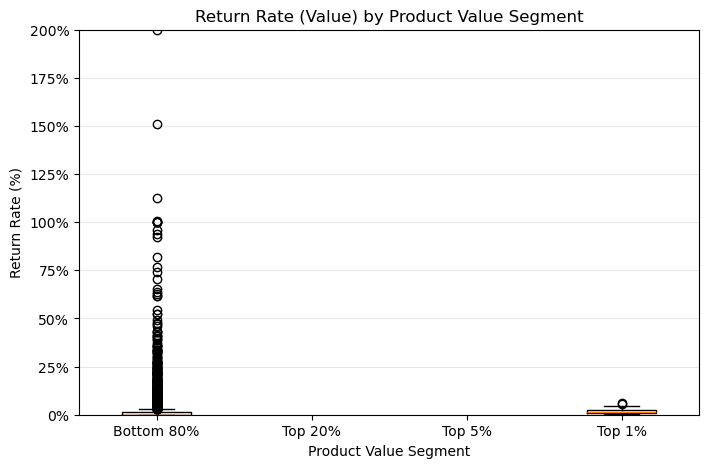

In [366]:
plot_df = product_returns[
    product_returns["Sales_Revenue"] > 0
].copy()

import matplotlib.ticker as mtick

segments = ["Bottom 80%", "Top 20%", "Top 5%", "Top 1%"]

data = [
    plot_df.loc[plot_df["Value_segment"] == seg, "Return_Rate_Value"]
    for seg in segments
]

plt.figure(figsize=(8, 5))
plt.boxplot(data, tick_labels=segments, showfliers=True)

plt.title("Return Rate (Value) by Product Value Segment")
plt.xlabel("Product Value Segment")
plt.ylabel("Return Rate (%)")
plt.ylim(0, 2)  # 0% à 200%  : L’axe vertical du graphique a été limité à 0–200 % afin d’améliorer la lisibilité.

# Axe Y en pourcentage
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.grid(axis="y", alpha=0.3)
plt.show()

# Les produits à faible valeur concentrent la majorité des anomalies de retour,
# tandis que les produits à forte valeur (Top 5 % et Top 1 %) présentent des taux de retour plus stables et mieux contrôlés.

In [367]:
product_returns["Return_Rate_Value_%"] = (
    product_returns["Return_Rate_Value"] * 100
).round(2)

product_returns[
    
    [
        "Description",
        "Sold_Qty",
        "Returned_Qty",
        "Sales_Revenue",
        "Returned_Revenue",
        "Return_Rate_Value_%",
        "Net_Revenue",
        "Value_segment"
    ]
].sort_values("Return_Rate_Value_%", ascending=False,na_position="last").head(10)

# Les taux de retours supérieurs à 100 % reflètent des situations où la valeur des retours dépasse le revenu généré par les ventes.
# Ces cas, concentrés parmi les produits à faible contribution, traduisent des anomalies transactionnelles typiques 
# dans des données réelles.

,Description,Sold_Qty,Returned_Qty,Sales_Revenue,Returned_Revenue,Return_Rate_Value_%,Net_Revenue,Value_segment
StockCode,,,,,,,,
20703,BLUE PADDED SOFT MOBILE,1,7,4.25,29.75,700.00,-25.50,Bottom 80%
79323P,PINK CHERRY LIGHTS,4,8,27.00,54.00,200.00,-27.00,Bottom 80%
35400,WOODEN BOX ADVENT CALENDAR,10,16,89.50,135.20,151.06,-45.70,Bottom 80%
84750A,PINK SMALL GLASS CAKE STAND,24,27,46.80,52.65,112.50,-5.85,Bottom 80%
22034,ROBIN CHRISTMAS CARD,10,12,5.02,5.04,100.40,-0.02,Bottom 80%
23843,"PAPER CRAFT , LITTLE BIRDIE",80995,80995,168469.60,168469.60,100.00,0.00,Bottom 80%
21655,HANGING RIDGE GLASS T-LIGHT HOLDER,36,36,60.84,60.84,100.00,0.00,Bottom 80%
79323B,BLACK CHERRY LIGHTS,8,8,54.00,54.00,100.00,0.00,Bottom 80%
21667,GLASS CAKE COVER AND PLATE,2,2,29.90,29.90,100.00,0.00,Bottom 80%


In [368]:
heatmap_df2 = product_returns.copy()

# Sales bins (ok)
heatmap_df2["Sales_Bin"] = pd.qcut(
    heatmap_df2["Sales_Revenue"],
    q=4,
    labels=["Low Sales", "Medium-Low", "Medium-High", "High Sales"],
    duplicates="drop"
)

# Return bins : 0 vs non-zero
heatmap_df2["Return_Bin"] = "No returns (0%)"

mask = heatmap_df2["Return_Rate_Value"] > 0
heatmap_df2.loc[mask, "Return_Bin"] = pd.qcut(
    heatmap_df2.loc[mask, "Return_Rate_Value"],
    q=3,  # 3 bins pour les non-zéro
    labels=["Low Returns", "Medium Returns", "High Returns"],
    duplicates="drop"
).astype(str)



pivot = pd.crosstab(
    heatmap_df2["Sales_Bin"],
    heatmap_df2["Return_Bin"],
    normalize="index"
) * 100



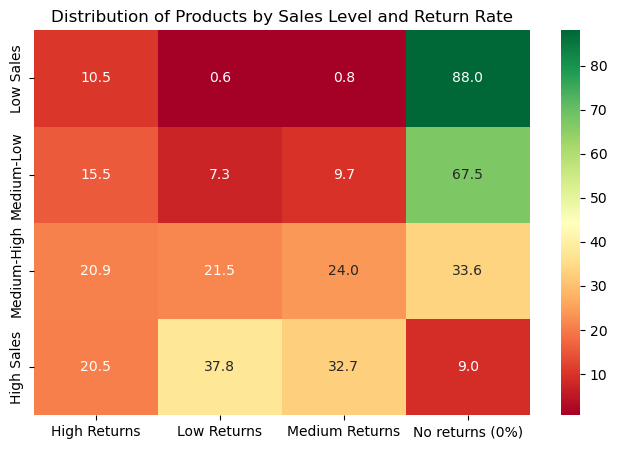

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn")
plt.title("Distribution of Products by Sales Level and Return Rate")
plt.xlabel("")
plt.ylabel("")
plt.show()

# La heatmap met en évidence une relation claire entre le niveau des ventes et le comportement de retour des produits.
# Les produits à faibles ventes sont majoritairement associés à l'absence de retours enregistrés, tandis que les produits à fortes ventes
# présentent presque toujours des retours, généralement à des niveaux modérés.
# Les taux de retour extrêmes sont plus fréquents parmi les produits ayant des ventes faibles à moyennes.

In [370]:
total_sales_revenue = df_sales.loc[df_sales["Revenue"] > 0, "Revenue"].sum()
total_returned_revenue = -df_sales.loc[df_sales["Revenue"] < 0, "Revenue"].sum()

global_return_rate_value = total_returned_revenue / total_sales_revenue

f"{global_return_rate_value*100:.2f}%"
# Le taux global de retour en valeur est de 4,66 %

'4.66%'

In [ ]:
# Export des datasets nettoyés :

df_sales.to_csv("export/sales.csv", index=False)

Customers = Customer_by_revenue.reset_index()[['CustomerID','Value_segment']].copy()
Customers.to_csv("export/customers.csv", index=False)

Returns = product_returns.reset_index()[['StockCode','Value_segment']].copy()
Returns.to_csv("export/returns.csv", index=False)

Products = Product_by_revenue.reset_index()[['StockCode','Value_segment']].copy()
Products.to_csv("export/products.csv", index=False)


